# MSCS 634 – Advanced Data Mining
## Project Deliverable 1: Data Collection, Cleaning, and Exploration
**Dataset:** Titanic Passenger Survival Dataset  
**Source:** Kaggle / UCI Machine Learning Repository  


---
## 2. Setup: Import Libraries

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Stats ────────────────────────────────────────────────────────────────────
from scipy import stats

# ─── Display Settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


---
## 3. Load the Dataset and Inspect Structure

In [2]:
# ─── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv('titanic.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n── First 5 rows ──")
df.head()

Dataset shape: 891 rows × 12 columns

── First 5 rows ──


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [3]:
# ─── Data Types and Non-null Counts ───────────────────────────────────────────
print("── Data Types & Non-Null Counts ──")
df.info()

── Data Types & Non-Null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# ─── Statistical Summary ──────────────────────────────────────────────────────
print("── Descriptive Statistics (Numeric Columns) ──")
df.describe()

── Descriptive Statistics (Numeric Columns) ──


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [5]:
# ─── Categorical Summary ──────────────────────────────────────────────────────
print("── Descriptive Statistics (Categorical Columns) ──")
df.describe(include=['object'])

── Descriptive Statistics (Categorical Columns) ──


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


---
## 4. Data Cleaning
### 4.1 Missing Value Analysis

── Missing Values Summary ──
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


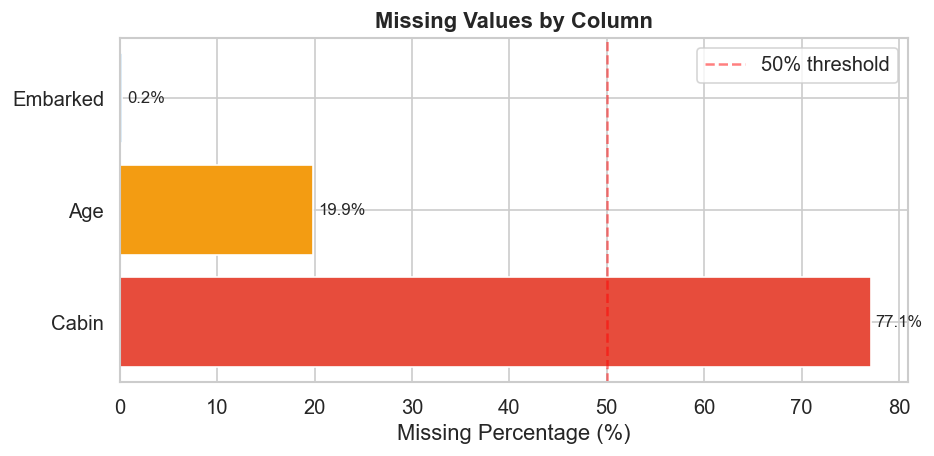


💡 Insight: Cabin has ~77% missing data → drop. Age has ~20% missing → impute. Embarked has 2 missing → impute with mode.


In [6]:
# ─── Missing Value Summary ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("── Missing Values Summary ──")
print(missing_df)

# ─── Visualize Missing Values ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 10 else '#3498db'
          for x in missing_df['Missing %']]
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column', fontweight='bold')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_missing_values.png', bbox_inches='tight')
plt.show()
print("\n💡 Insight: Cabin has ~77% missing data → drop. Age has ~20% missing → impute. Embarked has 2 missing → impute with mode.")

### 4.2 Handle Missing Values

In [7]:
# ─── Strategy 1: Drop 'Cabin' (77.1% missing — too sparse to impute reliably) ─
df.drop(columns=['Cabin'], inplace=True)
print("✅ Dropped 'Cabin' column (77.1% missing).")

# ─── Strategy 2: Impute 'Age' with median (robust to outliers) ────────────────
# We use median instead of mean because Age has outliers (elderly passengers)
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)
print(f"✅ Imputed 'Age' missing values with median: {age_median:.1f} years.")

# ─── Strategy 3: Impute 'Embarked' with mode (only 2 missing) ─────────────────
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"✅ Imputed 'Embarked' missing values with mode: '{embarked_mode}'.")

# ─── Confirm no more missing values ──────────────────────────────────────────
print(f"\n✅ Remaining missing values: {df.isnull().sum().sum()}")

✅ Dropped 'Cabin' column (77.1% missing).
✅ Imputed 'Age' missing values with median: 28.0 years.
✅ Imputed 'Embarked' missing values with mode: 'S'.

✅ Remaining missing values: 0


### 4.3 Remove Duplicates

In [8]:
# ─── Check for duplicate rows ─────────────────────────────────────────────────
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ Removed {n_duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("✅ No duplicate rows — dataset is clean.")

Duplicate rows found: 0
✅ No duplicate rows — dataset is clean.


### 4.4 Detect and Handle Outliers (Noisy Data)

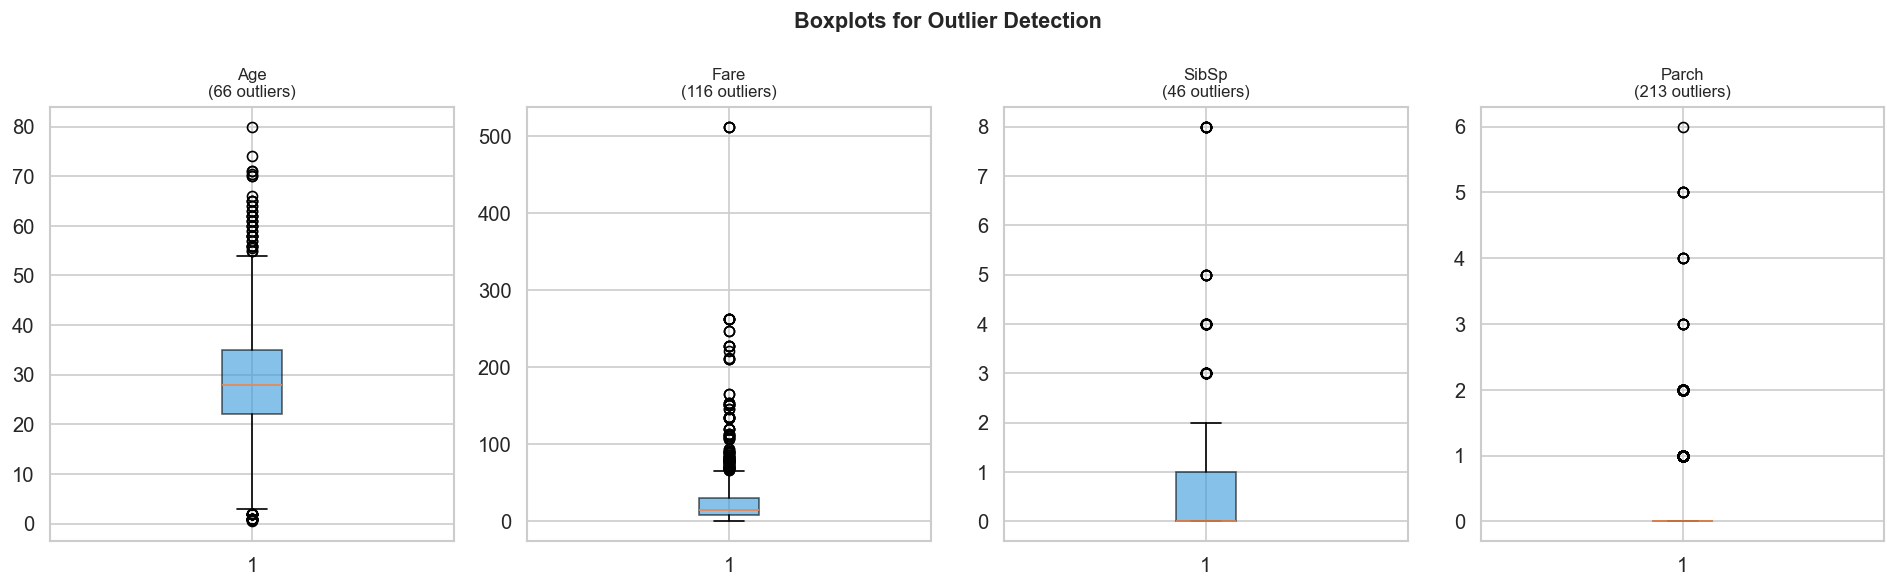

── IQR Outlier Summary ──


,Q1,Q3,IQR,Lower,Upper,Outliers
Age,22.00,35.00,13.00,2.50,54.50,66.00
Fare,7.91,31.00,23.09,-26.72,65.63,116.00
SibSp,0.00,1.00,1.00,-1.50,2.50,46.00
Parch,0.00,0.00,0.00,0.00,0.00,213.00


In [9]:
# ─── Outlier Detection using IQR method ──────────────────────────────────────
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
fig.suptitle('Boxplots for Outlier Detection', fontweight='bold', fontsize=13)

outlier_report = {}
for ax, col in zip(axes, numeric_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Lower': lower, 'Upper': upper, 'Outliers': n_out}
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

print("── IQR Outlier Summary ──")
pd.DataFrame(outlier_report).T.round(2)

In [10]:
# ─── Decision: Cap 'Fare' outliers using IQR upper bound (Winsorization) ──────
# Extreme fares (e.g., $512) are valid but can distort models — we cap rather than remove.
fare_upper = df['Fare'].quantile(0.75) + 1.5 * (df['Fare'].quantile(0.75) - df['Fare'].quantile(0.25))
n_capped = (df['Fare'] > fare_upper).sum()
df['Fare'] = df['Fare'].clip(upper=fare_upper)
print(f"✅ Capped {n_capped} Fare outliers at upper bound: £{fare_upper:.2f}")

# Age: No capping — elderly passengers (max ~80) are plausible real-world values
print("✅ Age outliers retained — values are domain-valid (young children to elderly).")

✅ Capped 116 Fare outliers at upper bound: £65.63
✅ Age outliers retained — values are domain-valid (young children to elderly).


### 4.5 Fix Inconsistencies & Data Type Corrections

In [11]:
# ─── Verify and cast data types ───────────────────────────────────────────────
df['Survived'] = df['Survived'].astype(int)          # Ensure binary integer
df['Pclass']   = df['Pclass'].astype('category')     # Ordinal categorical
df['Sex']      = df['Sex'].astype('category')        # Nominal categorical
df['Embarked'] = df['Embarked'].astype('category')   # Nominal categorical

# ─── Standardize 'Sex' values (ensure no casing issues) ──────────────────────
df['Sex'] = df['Sex'].str.lower().str.strip()

print("✅ Data types corrected.")
print(df.dtypes)
print(f"\n✅ Final cleaned dataset shape: {df.shape}")

✅ Data types corrected.
PassengerId       int64
Survived          int64
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object

✅ Final cleaned dataset shape: (891, 11)


---
## 5. Exploratory Data Analysis (EDA)
### 5.1 Target Variable Distribution

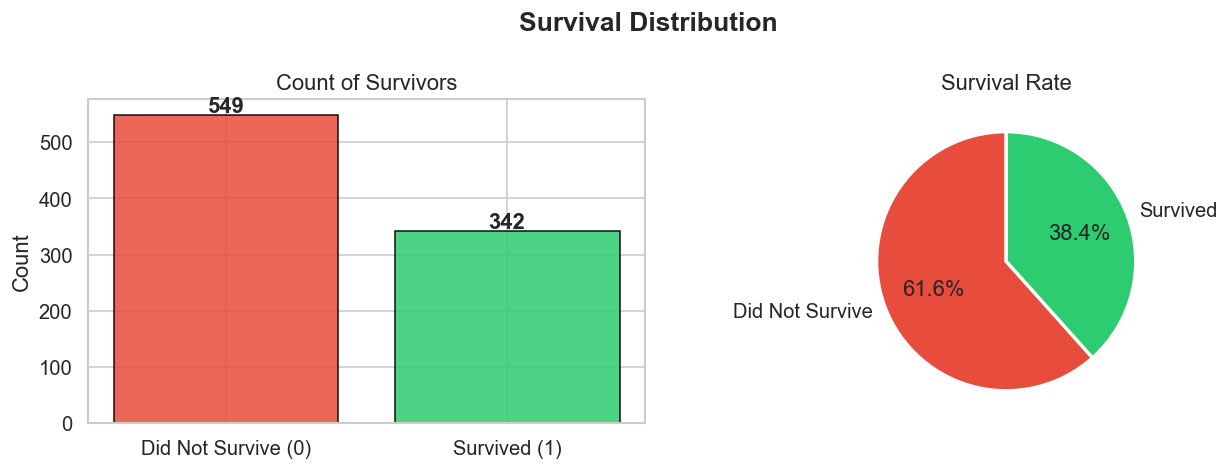


💡 Insight: Only 38.4% of passengers survived — the dataset is moderately imbalanced (≈38/62 split).


In [12]:
# ─── Survival Rate Overview ───────────────────────────────────────────────────
survival_counts = df['Survived'].value_counts()
survival_pct = df['Survived'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Survival Distribution', fontweight='bold')

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Did Not Survive (0)', 'Survived (1)'], survival_counts, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylabel('Count')
axes[0].set_title('Count of Survivors')
for i, v in enumerate(survival_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survival_pct, labels=['Did Not Survive', 'Survived'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Rate')

plt.tight_layout()
plt.savefig('fig_survival_dist.png', bbox_inches='tight')
plt.show()
print(f"\n💡 Insight: Only {survival_pct[1]:.1f}% of passengers survived — the dataset is moderately imbalanced (≈38/62 split).")

### 5.2 Survival by Key Categorical Features

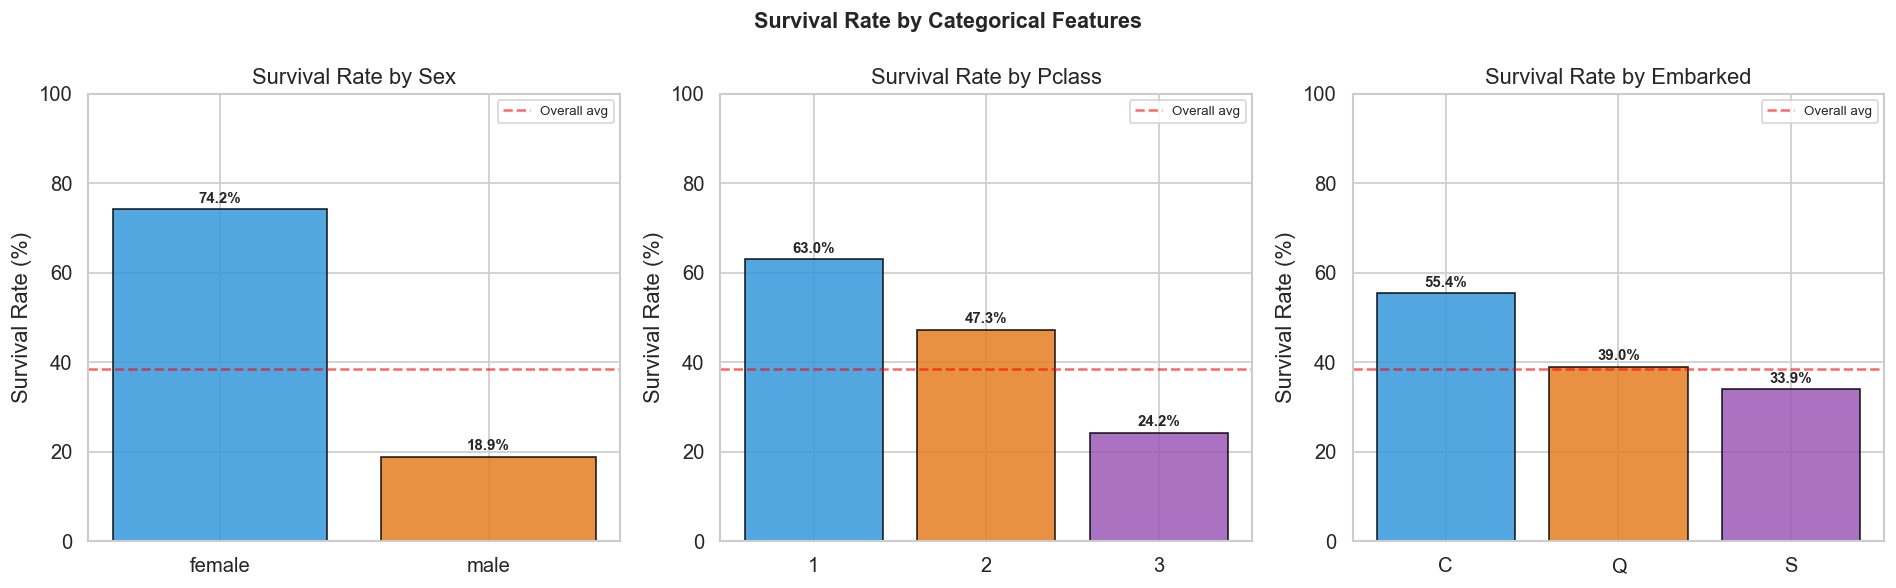

💡 Insights:
   • Female survival rate: 74.2% vs Male: 18.9%
   • 1st class survival: 63.0% vs 3rd class: 24.2%


In [13]:
# ─── Survival Rate by Sex, Pclass, and Embarked ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Survival Rate by Categorical Features', fontweight='bold', fontsize=13)

cat_features = ['Sex', 'Pclass', 'Embarked']
palette = {'0': '#e74c3c', '1': '#2ecc71', 0: '#e74c3c', 1: '#2ecc71'}

for ax, feat in zip(axes, cat_features):
    survival_rate = df.groupby(feat)['Survived'].mean() * 100
    bars = ax.bar(survival_rate.index.astype(str), survival_rate.values,
                  color=['#3498db', '#e67e22', '#9b59b6'][:len(survival_rate)],
                  edgecolor='black', alpha=0.85)
    ax.set_ylabel('Survival Rate (%)')
    ax.set_title(f'Survival Rate by {feat}')
    ax.set_ylim(0, 100)
    ax.axhline(df['Survived'].mean() * 100, color='red', linestyle='--', alpha=0.6, label='Overall avg')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, survival_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_survival_categorical.png', bbox_inches='tight')
plt.show()
print("💡 Insights:")
print(f"   • Female survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}% vs Male: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"   • 1st class survival: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}% vs 3rd class: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")

### 5.3 Age and Fare Distributions

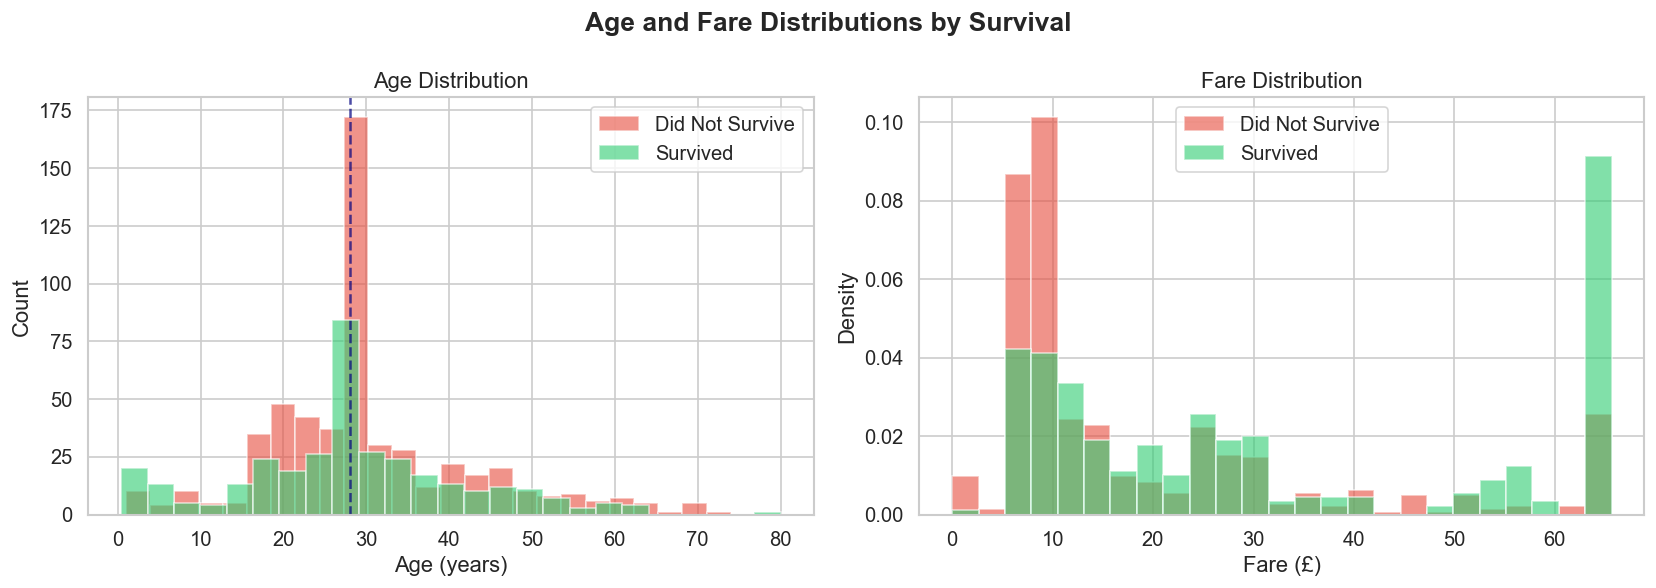

💡 Insights:
   • Children (Age < 10) show higher survival rates — 'women and children first' policy evident.
   • Passengers who paid higher fares (wealthier/1st class) are more likely to have survived.


In [14]:
# ─── Age Distribution by Survival Status ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age and Fare Distributions by Survival', fontweight='bold')

# Age histogram
for survived, color, label in [(0, '#e74c3c', 'Did Not Survive'), (1, '#2ecc71', 'Survived')]:
    axes[0].hist(df[df['Survived'] == survived]['Age'], bins=25, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution')
axes[0].legend()
axes[0].axvline(df['Age'].median(), color='navy', linestyle='--', alpha=0.7, label='Median Age')

# Fare KDE
for survived, color, label in [(0, '#e74c3c', 'Did Not Survive'), (1, '#2ecc71', 'Survived')]:
    subset = df[df['Survived'] == survived]['Fare']
    axes[1].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white', density=True)
axes[1].set_xlabel('Fare (£)')
axes[1].set_ylabel('Density')
axes[1].set_title('Fare Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_age_fare_dist.png', bbox_inches='tight')
plt.show()
print("💡 Insights:")
print("   • Children (Age < 10) show higher survival rates — 'women and children first' policy evident.")
print("   • Passengers who paid higher fares (wealthier/1st class) are more likely to have survived.")

### 5.4 Family Size Analysis

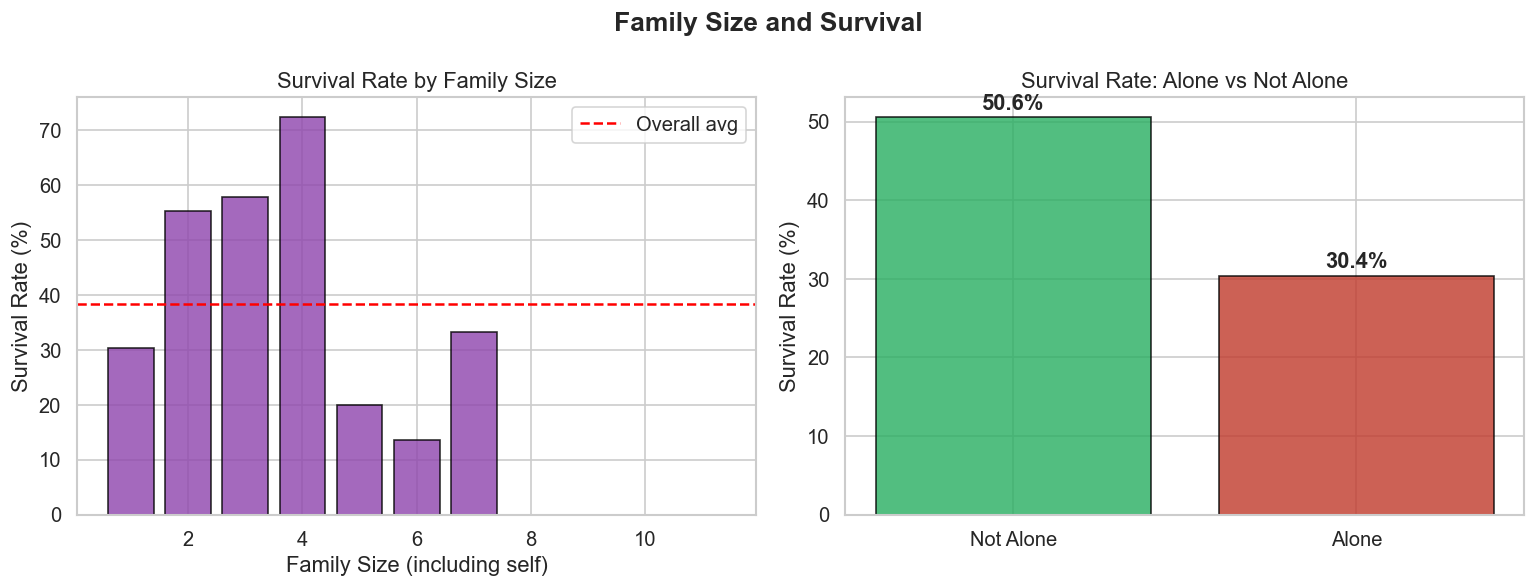

💡 Insight: Small families (2-4 members) had higher survival rates. Solo travelers and very large families fared worse.


In [15]:
# ─── Engineer 'FamilySize' and 'IsAlone' ──────────────────────────────────────
# FamilySize = number of family members on board (including the passenger)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Family Size and Survival', fontweight='bold')

# Survival rate by FamilySize
fam_survival = df.groupby('FamilySize')['Survived'].mean() * 100
axes[0].bar(fam_survival.index, fam_survival.values, color='#8e44ad', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Family Size (including self)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Survival Rate by Family Size')
axes[0].axhline(df['Survived'].mean() * 100, color='red', linestyle='--', label='Overall avg')
axes[0].legend()

# Alone vs Not Alone
alone_survival = df.groupby('IsAlone')['Survived'].mean() * 100
axes[1].bar(['Not Alone', 'Alone'], alone_survival.values, color=['#27ae60', '#c0392b'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_title('Survival Rate: Alone vs Not Alone')
for i, v in enumerate(alone_survival.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_family_survival.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Small families (2-4 members) had higher survival rates. Solo travelers and very large families fared worse.")

### 5.5 Heatmap: Feature Correlations

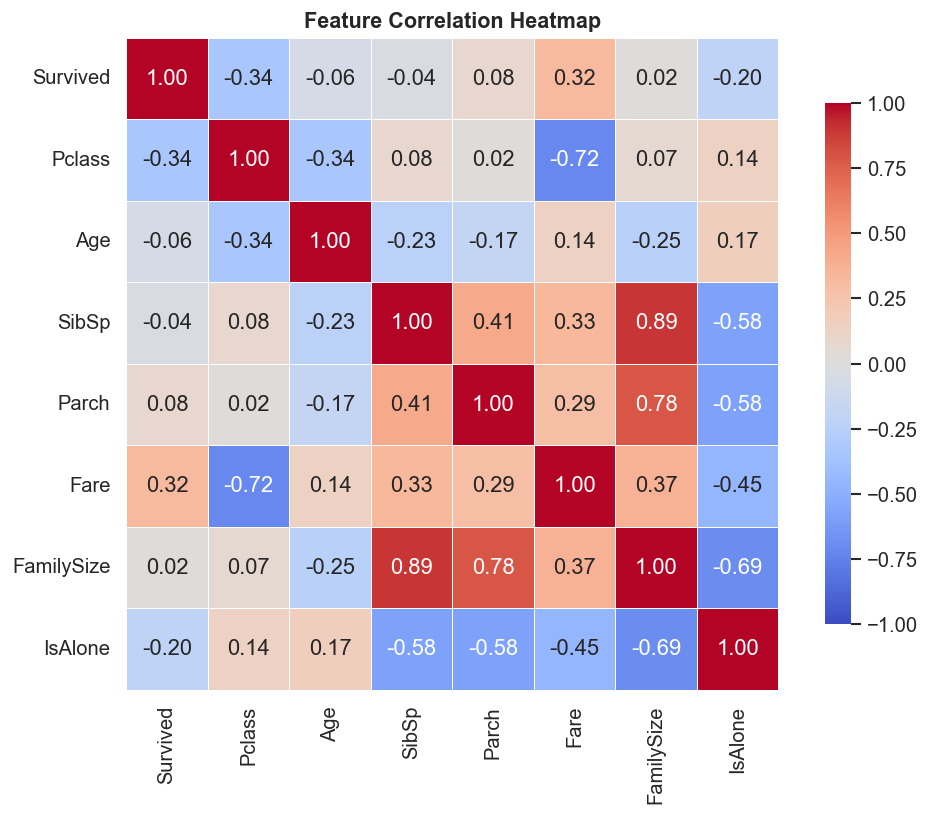

── Correlations with 'Survived' ──
Pclass       -0.34
Fare          0.32
IsAlone      -0.20
Parch         0.08
Age          -0.07
SibSp        -0.04
FamilySize    0.02
Name: Survived, dtype: float64


In [16]:
# ─── Correlation Matrix (numeric features only) ───────────────────────────────
corr_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']].copy()
corr_df['Pclass'] = corr_df['Pclass'].astype(int)  # Convert for correlation calc

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Show lower triangle only
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with Survived
print("── Correlations with 'Survived' ──")
print(corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3))

### 5.6 Pairplot: Multi-Feature Relationships

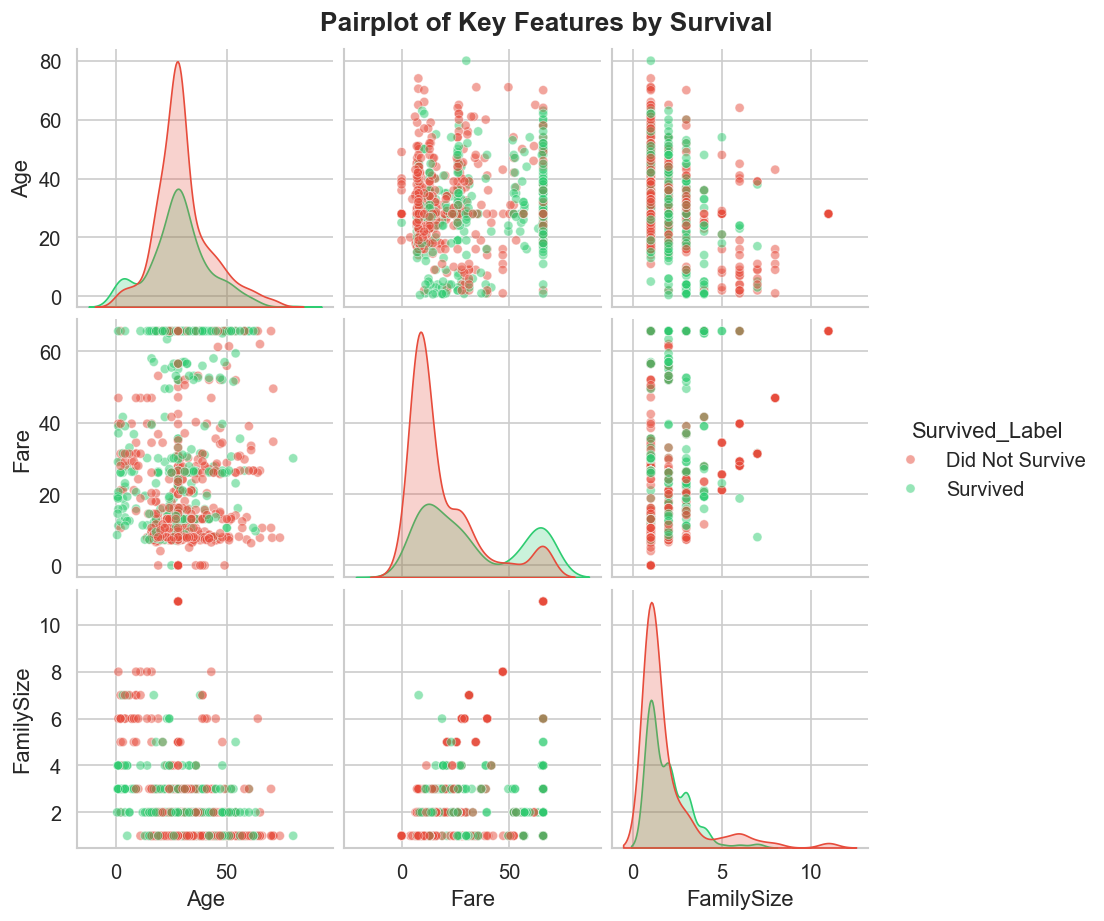

💡 Insight: Fare shows stronger separation between survivors and non-survivors compared to Age.


In [17]:
# ─── Pairplot for Key Numeric Features ───────────────────────────────────────
pair_cols = ['Age', 'Fare', 'FamilySize', 'Survived']
pair_df = df[pair_cols].copy()
pair_df['Survived_Label'] = pair_df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

g = sns.pairplot(pair_df.drop(columns='Survived'), hue='Survived_Label',
                 palette=['#e74c3c', '#2ecc71'], diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 30})
g.fig.suptitle('Pairplot of Key Features by Survival', y=1.02, fontweight='bold')
plt.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Fare shows stronger separation between survivors and non-survivors compared to Age.")

### 5.7 Age Group Analysis

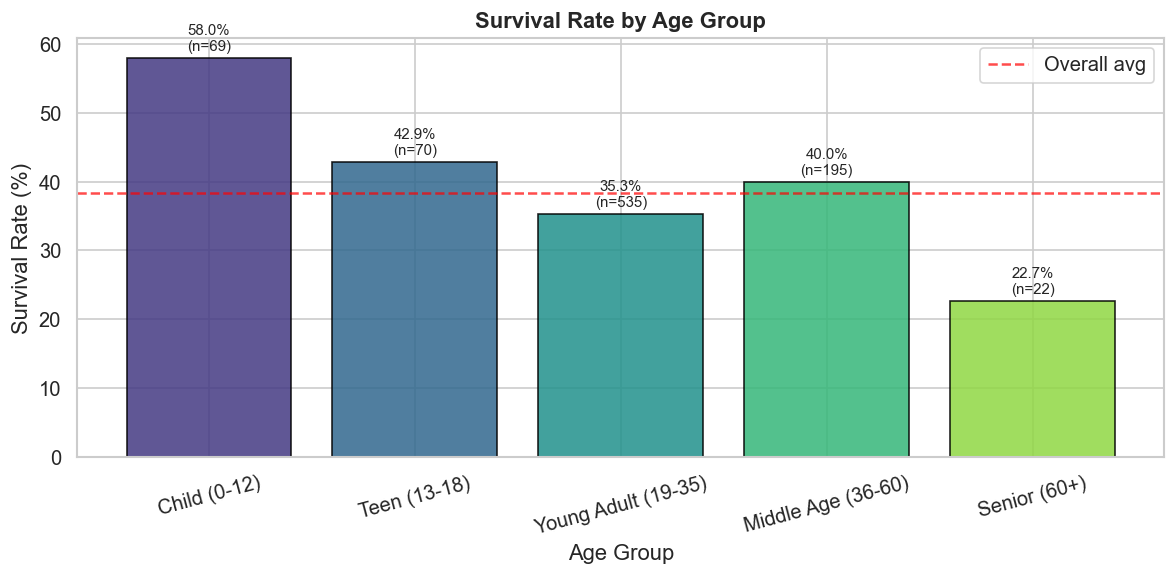

💡 Insight: Children had the highest survival rate, consistent with evacuation prioritization.


In [18]:
# ─── Binning Age into Groups ──────────────────────────────────────────────────
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Middle Age (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 5))
age_surv = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
age_count = df['AgeGroup'].value_counts().sort_index()

bars = ax.bar(age_surv.index.astype(str), age_surv.values,
              color=sns.color_palette('viridis', len(age_surv)), edgecolor='black', alpha=0.85)
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Survival Rate by Age Group', fontweight='bold')
ax.axhline(df['Survived'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Overall avg')

# Annotate with counts
for bar, val, count in zip(bars, age_surv.values, age_count):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%\n(n={count})', ha='center', fontsize=9)

ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig_age_group_survival.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Children had the highest survival rate, consistent with evacuation prioritization.")

### 5.8 Stacked Survival Heatmap: Sex × Pclass

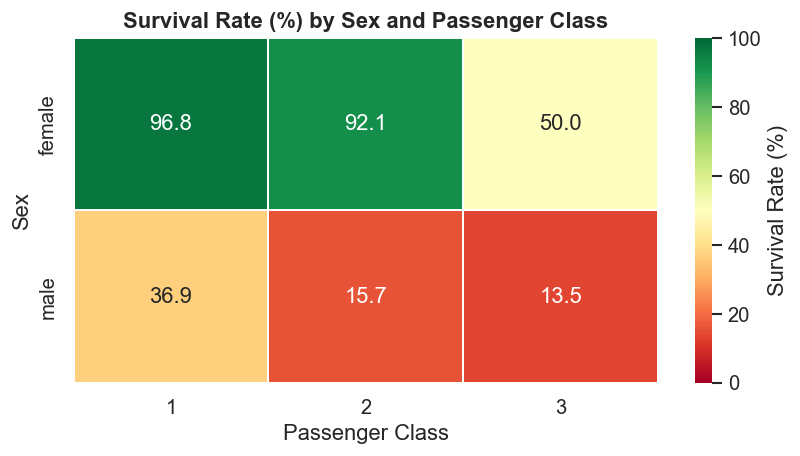

Pclass     1     2     3
Sex                     
female 96.80 92.10 50.00
male   36.90 15.70 13.50

💡 Insight: 1st-class females had a ~97% survival rate. 3rd-class males had only ~13% survival.


In [19]:
# ─── Pivot Table: Survival Rate by Sex and Pclass ────────────────────────────
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=1, cbar_kws={'label': 'Survival Rate (%)'})
ax.set_title('Survival Rate (%) by Sex and Passenger Class', fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Sex')
plt.tight_layout()
plt.savefig('fig_sex_pclass_heatmap.png', bbox_inches='tight')
plt.show()
print(pivot.round(1))
print("\n💡 Insight: 1st-class females had a ~97% survival rate. 3rd-class males had only ~13% survival.")

---
## 6. Summary of Cleaned Dataset

In [20]:
# ─── Final Dataset Preview ────────────────────────────────────────────────────
print(f"Final Dataset Shape: {df.shape}")
print(f"\nColumns in final dataset: {list(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nSurvival Rate: {df['Survived'].mean()*100:.1f}%")
print("\n── Sample of Cleaned Data ──")
df.head(10)

Final Dataset Shape: (891, 14)

Columns in final dataset: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']

Missing values: 0

Survival Rate: 38.4%

── Sample of Cleaned Data ──


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,S,2,0,Young Adult (19-35)
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,65.63,C,2,0,Middle Age (36-60)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,S,1,1,Young Adult (19-35)
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,S,2,0,Young Adult (19-35)
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,S,1,1,Young Adult (19-35)
5,6,0,3,"Moran, Mr. James",male,28.00,0,0,330877,8.46,Q,1,1,Young Adult (19-35)
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.86,S,1,1,Middle Age (36-60)
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.07,S,5,0,Child (0-12)
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.13,S,3,0,Young Adult (19-35)
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.07,C,2,0,Teen (13-18)


In [21]:
# ─── Save cleaned dataset for future deliverables ────────────────────────────
df.to_csv('titanic_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'titanic_cleaned.csv' for use in Deliverables 2–4.")

✅ Cleaned dataset saved as 'titanic_cleaned.csv' for use in Deliverables 2–4.
